In [1]:
import math
import dataclasses
import functools
import numpy
import matplotlib.pyplot as plt
from hypothesis import given, strategies as st

In [2]:
def dbg(value):
    print(value)
    return value

In [3]:
def dB(p: float, p_0: float) -> float:
    return 10 * math.log10(p / p_0)

In [4]:
def bin(sample_rate: int, frequency: int, window_size: int) -> int:
    return int(round((frequency * window_size) / sample_rate))

assert [bin(9600, f, 32) for f in [1200, 2400]] == [4, 8]

In [5]:
@dataclasses.dataclass(frozen=True)
class Spec:
    sample_rate: int
    mark_frequency: int
    space_frequency: int

    @classmethod
    def with_kcs(cls) -> "Spec":
        return cls(9600, 2400, 1200)

In [6]:
@dataclasses.dataclass(frozen=True)
class DftTerm:
    frequency: int
    w_real: float
    w_imag: float
    d1: float
    d2: float

    def power(self) -> float:
        return math.pow(self.d2, 2) + math.pow(self.d1, 2) - self.w_real * self.d1 * self.d2

In [7]:
@dataclasses.dataclass(frozen=True)
class Output:
    mark: DftTerm
    space: DftTerm

In [8]:
def goertzel_inner_loop(state: (float, float), sample: int, *, w_real: float = float("nan")) -> (float, float):
    (d1, d2) = state
    y = sample + w_real * d1 - d2
    return (y, d1)


def goertzel_single_term(sample_rate: int, frequency: int, data: list[int]) -> DftTerm:
    window_size = len(data)
    #k = bin(sample_rate, frequency, window_size)
    f = frequency / sample_rate
    wt = 2 * math.pi * f
    w_real = 2 * math.cos(wt)
    w_imag = math.sin(wt)

    (d1, d2) = functools.reduce(
        functools.partial(goertzel_inner_loop, w_real=w_real), 
        data, 
        (0, 0),
    )

    return DftTerm(
        frequency,
        w_real,
        w_imag,
        d1,
        d2,
    )

    
def goertzel(spec: Spec, data: list[int]) -> Output:
    return Output(
        goertzel_single_term(spec.sample_rate, spec.mark_frequency, data),
        goertzel_single_term(spec.sample_rate, spec.space_frequency, data),
    )

def hamming(window_size: int):
    alpha = 25 / 46
    beta = 1 - alpha
    return (alpha - beta * math.cos(math.tau * t / (window_size - 1)) for t in range(0, window_size))

In [9]:
def plot_power_spectrum(window: str):
    i8_max = 255
    window_size = 32
    spec = Spec.with_kcs()
    freqs = numpy.arange(1, 4800)
    t = numpy.linspace(0, 1, spec.sample_rate)[:window_size]
    vlines = [spec.mark_frequency, spec.space_frequency]
    data = [i8_max * numpy.sin(2 * numpy.pi * f * t) for f in freqs]
    match window:
        case 'hamming': window_val = numpy.hamming(window_size)
        case 'custom': window_val = numpy.array(list(hamming(window_size)))
        case _: window_val = 1
    output = [goertzel(spec, d) for d in data]
    mark_power = numpy.array([o.mark.power() for o in output])
    space_power = numpy.array([o.space.power() for o in output])
   
    windowed_data = [d * window_val for d in data]
    windowed_output = [goertzel(spec, d) for d in windowed_data]
    windowed_mark_power = numpy.array([o.mark.power() for o in windowed_output])
    windowed_space_power = numpy.array([o.space.power() for o in windowed_output])
    mark_main_lobe = freqs[numpy.where(windowed_mark_power > 1e4)]
    print(f"mark_main_lobe={mark_main_lobe[0]}:{mark_main_lobe[-1]}")
    space_main_lobe = freqs[numpy.where(windowed_space_power > 1e4)]
    print(f"space_main_lobe={space_main_lobe[0]}:{space_main_lobe[-1]}")
    
    fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12,6), dpi=100, layout='constrained')
    ax[0, 0].plot(freqs, mark_power)
    ax[0, 0].plot(freqs, space_power)
    ax[0, 0].set_title('Goertzel Power Spectrum')
    ax[0, 0].set_xlabel('frequency (Hz)')
    ax[0, 0].set_ylabel('power')
    ax[0, 0].set_yscale('log')
    ax[0, 0].vlines(vlines, 0, 1, transform=ax[0, 0].get_xaxis_transform(), colors='r')

    ax[0, 1].plot(freqs, windowed_mark_power)
    ax[0, 1].plot(freqs, windowed_space_power)
    ax[0, 1].set_title(f'Goertzel Power Spectrum ({window=})')
    ax[0, 1].set_xlabel('frequency (Hz)')
    ax[0, 1].set_ylabel('power')
    ax[0, 1].set_yscale('log')
    ax[0, 1].vlines(vlines, 0, 1, transform=ax[0, 1].get_xaxis_transform(), colors='r')
    
    ax[1, 0].plot(
        freqs, 
        numpy.array([dB(o.mark.power(), o.space.power()) for o in output]),
    )
    ax[1, 0].set_title('Goertzel Power Spectrum (dB)')
    ax[1, 0].set_xlabel('frequency (Hz)')
    ax[1, 0].set_ylabel('$dB_{mark~vs.~space}$')
    ax[1, 0].vlines(vlines, 0, 1, transform=ax[1, 0].get_xaxis_transform(), colors='r')
       
    ax[1, 1].plot(
        freqs, 
        numpy.array([dB(o.mark.power(), o.space.power()) for o in windowed_output]),
    )
    ax[1, 1].set_title(f'Goertzel Power Spectrum (dB; {window=})')
    ax[1, 1].set_xlabel('frequency (Hz)')
    ax[1, 1].set_ylabel('$dB_{mark~vs.~space}$')
    ax[1, 1].vlines(vlines, 0, 1, transform=ax[1, 1].get_xaxis_transform(), colors='r')

mark_main_lobe=1875:2924
space_main_lobe=674:1724


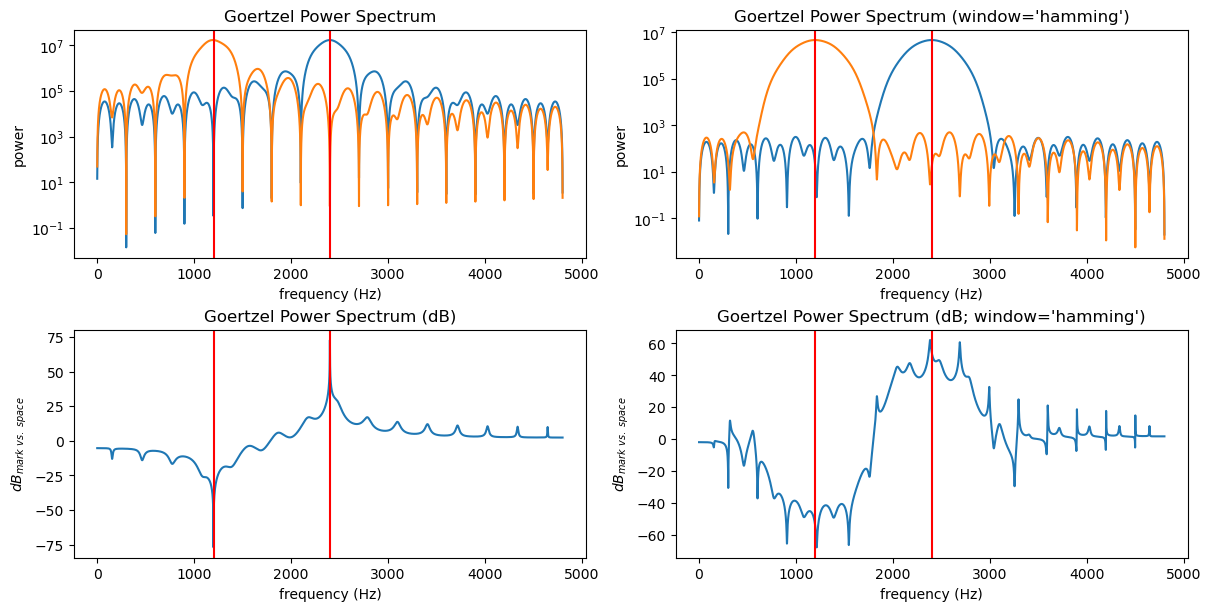

In [10]:
plot_power_spectrum('hamming')

In [11]:
def _test_goertzel_power(freq: int, mark: bool, space: bool):
    power_threshold = 1e4
    spec = Spec.with_kcs()
    window_size = 32
    i8_max = 255
    t = numpy.linspace(0, 1, spec.sample_rate)[:window_size]
    data = (i8_max * numpy.sin(2 * numpy.pi * freq * t) * numpy.hamming(window_size))
    output = goertzel(spec, data)
    dft_terms = [output.mark, output.space]

    match (mark, space):
        case (True, False): assert output.mark.power() >= power_threshold
        case (False, True): assert output.space.power() >= power_threshold
        case _: assert output.mark.power() < power_threshold and output.space.power() < power_threshold

In [12]:
@given(st.integers(674, 1724))
def test_goertzel_power_space(freq: int):
    _test_goertzel_power(freq, False, True)


@given(st.integers(1875, 2924))
def test_goertzel_power_mark(freq: int):
    _test_goertzel_power(freq, True, False)


@given(st.one_of(st.integers(1, 673), st.integers(1725, 1874), st.integers(2925, 4800)))
def test_goertzel_power_out_of_bounds(freq: int):
    _test_goertzel_power(freq, False, False)


test_goertzel_power_space()
test_goertzel_power_mark()
test_goertzel_power_out_of_bounds()